## MOLECULAR SUBTYPE STUDY

### Model 1: Feature Selection with Recursive Feature Elimination with Cross-Validation (RFE-CV)

In [1]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
# Main directory where all analysis results will be stored
path = "../results/MolecularSubtype_Model1"
input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

# Create the output directory
os.makedirs(path, exist_ok=True)

# Feature selection method used in this analysis
feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace commas with dots 
db = db.replace(',', '.', regex=True)

# Replace empty strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Ensure DFS120 is stored as a numerical variable
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')

# Remove variables that are not required for this analysis
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Invaperin'], errors='ignore')

# Convert numerical variables to float
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']

for col in columns_float:
    if col in db.columns:
        db[col] = db[col].astype(float)

# Remove S100Intra_M from the analysis (extensive missing data) 
db = db.drop(columns=['S100Intra_M'], errors='ignore')

# Remove missing values and reset index
db = db.dropna().reset_index(drop=True)

print(f"Dataset shape after cleaning: {db.shape}")

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE THE BINARY TARGET VARIABLE
# ----------------------------------------------------------------------------------------------------------------------------
#   True  = Luminal A or Luminal B
#   False = Triple-negative or HER2-enriched
db['Luminal_binary'] = db['Luminal'].apply(
    lambda x: True if str(x).strip() in ['Luminal A', 'Luminal B'] else False
)

# Remove the original categorical Luminal variable after creating the target.
db = db.drop(columns=['Luminal'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.get_dummies(db, columns=['Grau', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])
db = db.drop(columns=['StatusDFS120_No'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variable_names = ['Age', 'Tumor Diameter', 'RE', 'RP', 'HER2', 'KI67', 'GangMeta',
                  'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-',
                  'CD21 Intra', 'CD21 ALN-', 'CD68 Intra', 'CD68 ALN-',
                  'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Luminal_binary',
                  'Histological Grade II', 'Histological Grade III',
                  'NodalStatus_Sin metastasis', 'Recurrence']

db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# ----------------------------------------------------------------------------------------------------------------------------
immune_features = ['CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']

clinicopathological_features = [
    'Age',
    'Tumor Diameter',
    'GangMeta',
    'Histological Grade II',
    'Histological Grade III',
    'NodalStatus_Sin metastasis',
    'Recurrence'
]

# Combine all features
all_features = immune_features + clinicopathological_features

# ----------------------------------------------------------------------------------------------------------------------------
# DATASET VERIFICATION
# ----------------------------------------------------------------------------------------------------------------------------
print("=" * 60)
print("DATASET SHAPE:", db.shape)
print()

print("TARGET (Luminal_binary) distribution:")
print(db['Luminal_binary'].value_counts())
print(f"  True  = Luminal (Luminal A + Luminal B)")
print(f"  False = No Luminal (Triple negatiu + HER2 enriched)")
print()

# Check immune features
print("IMMUNE FEATURES ({} total):".format(len(immune_features)))
for f in immune_features:
    print(f"  {f:20s} | min: {db[f].min():.3f} | max: {db[f].max():.3f} | mean: {db[f].mean():.3f} | NaN: {db[f].isna().sum()}")
print()

# Check clinicopathological features
print("CLINICOPATHOLOGICAL FEATURES ({} total):".format(len(clinicopathological_features)))
for f in clinicopathological_features:
    print(f"  {f:30s} | unique values: {sorted(db[f].unique())} | NaN: {db[f].isna().sum()}")
print()

# Identify columns not used as predictors
print("COLUMNS NOT USED AS FEATURES (present in db but excluded):")
excluded = [c for c in db.columns if c not in all_features and c != 'Luminal_binary']
for c in excluded:
    print(f"  {c:20s} | unique values: {sorted(db[c].unique())}")
print()

# Display the complete column order
print("FULL COLUMN ORDER IN DB:")
for i, col in enumerate(db.columns):
    marker = "<-- TARGET" if col == "Luminal_binary" else ""
    used = "<-- FEATURE" if col in all_features else ""
    print(f"  [{i:02d}] {col:30s} {marker}{used}")
print("=" * 60)

variables_numericas = immune_features + ['Age', 'Tumor Diameter', 'GangMeta']


# ----------------------------------------------------------------------------------------------------------------------------
# PREPARE FEATURES AND TARGET
# ----------------------------------------------------------------------------------------------------------------------------
# Predictor matrix
x = db[all_features]

# Binary target variable
y = db['Luminal_binary']

print("\nOriginal distribution:")
print(Counter(y))


# ----------------------------------------------------------------------------------------------------------------------------
# REPEATED TRAIN/TEST ANALYSIS
# ----------------------------------------------------------------------------------------------------------------------------
# The complete analysis is repeated for 100 random states.
# Each iteration uses:
#   - 80% of the data for training
#   - 20% of the data for testing
#   - stratification to preserve the target-class distribution

for i in range(0, 100):
    random_num = i
    # Create a separate directory for each random state
    os.makedirs(f'{path}/{feature_selection_method}_METHOD/{random_num}', exist_ok=True)

    new_file = open(f'{path}/{feature_selection_method}_METHOD/{random_num}/resultats_terminal.txt', 'w')
    new_file.write('Random State: ' + str(random_num) + '\n')

    #----------------------------------------------------------------------
    # TRAIN/TEST SPLIT
    #----------------------------------------------------------------------
    x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2,random_state=random_num,shuffle = True,stratify=y)
    
    #----------------------------------------------------------------------
    # CHECK CLASS DISTRIBUTION
    #----------------------------------------------------------------------
    counter = Counter(y)
    counter_test = Counter(y_test)
    
    new_file.write('\n' + 'y: '+ str(counter) + '\n')
    new_file.write('y test: ' + str(counter_test) + '\n')
    counter = Counter(y_train)
    new_file.write('y train: ' +str(counter) + '\n')
    
    #----------------------------------------------------------------------
    # STANDARDIZATION
    #----------------------------------------------------------------------
    scaler = StandardScaler()
    scaler_fit = scaler.fit(x_train[variables_numericas]) 
    
    x_train_scaled = x_train.copy()
    x_train_scaled[variables_numericas] = scaler_fit.transform(x_train[variables_numericas])
    x_test_scaled = x_test.copy()
    x_test_scaled[variables_numericas] = scaler_fit.transform(x_test[variables_numericas])

    # ------------------------------------------------------------
    # RANDOMIZED HYPERPARAMETER SEARCH
    # ------------------------------------------------------------
    # Three-fold stratified cross-validation is used for model selection
    cv = StratifiedKFold(3)  
    
    # Hyperparameter search space for logistic regression
    param_dist = {
        'classifier__C': np.logspace(-3, 3, 20),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear'],
        'classifier__max_iter': [500, 1000, 2000]
    }

    # ROC AUC is used as the optimization metric
    scoring = 'roc_auc'
    new_file.write('\n' + 'Scoring: ' + str(scoring) + '\n') 

    #----------------------------------------------------------------------
    # DEFINE LOGISTIC REGRESSION CLASSIFIER
    #----------------------------------------------------------------------
    lr_classifier = LogisticRegression(class_weight='balanced', random_state=random_num)

    #----------------------------------------------------------------------
    # FEATURE SELECTION + RANDOMIZED SEARCH
    #----------------------------------------------------------------------  
    if x_train_scaled.shape[1]==1:
        # Skip feature selection if only one feature
        pipeline = Pipeline([
            ('classifier', lr_classifier)
        ])
        random_search = RandomizedSearchCV(estimator = pipeline, scoring = scoring, param_distributions = param_dist, cv = cv, verbose=0, random_state=random_num, n_jobs = -1)
        random_search.fit(x_train_scaled,y_train)
        x_train_rfecv = x_train_scaled
        x_test_rfecv = x_test_scaled

    else:
        # Include Recursive Feature Elimination (RFECV) for feature selection
        pipeline = Pipeline([
            ('feature_selection', RFECV(estimator=lr_classifier, step=1, cv=cv, scoring=scoring)),
            ('classifier', lr_classifier)
        ])
        # Randomized hyperparameter search with 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(estimator = pipeline, scoring = scoring, param_distributions = param_dist, cv = cv, verbose=0, random_state=random_num, n_jobs = -1)
        random_search.fit(x_train_scaled,y_train)

        # Get the selected features
        selected_features = x_train_scaled.columns[random_search.best_estimator_['feature_selection'].support_]
        
        # Transform the data to include only the selected features
        x_train_rfecv = random_search.best_estimator_['feature_selection'].transform(x_train_scaled)
        x_train_rfecv = pd.DataFrame(x_train_rfecv, columns=selected_features)
        x_test_rfecv = random_search.best_estimator_['feature_selection'].transform(x_test_scaled)
        x_test_rfecv = pd.DataFrame(x_test_rfecv, columns=selected_features)
         

    #----------------------------------------------------------------------
    # TRAIN FINAL LOGISTIC REGRESSION MODEL
    #----------------------------------------------------------------------
    # Retrieve the best hyperparameters identified by RandomizedSearchCV
    best_params = random_search.best_params_
    cleaned_best_params = {p.split('__')[1]: v for p, v in best_params.items()}
    
    # Create the final logistic regression model using the optimized hyperparameters
    best_lr = LogisticRegression(**cleaned_best_params, class_weight='balanced', random_state=random_num)

    # Fit the final model using the selected training features
    best_lr.fit(x_train_rfecv, y_train)
    
    # Generate predictions for the independent test set
    result_lr = best_lr.predict(x_test_rfecv)

    #----------------------------------------------------------------------
    # CROSS-VALIDATION PERFORMANCE
    #----------------------------------------------------------------------
    # Evaluate the final model using three-fold cross-validation on the training set
    scores = cross_val_score(best_lr, x_train_rfecv, y_train,cv=cv, scoring=scoring)
    new_file.write('\n' + 'Metricas cross_validation: ' + str(scores) )
    new_file.write('\n' + 'Media de cross_validation: ' + str(scores.mean()) +' ' + str(np.std(scores)) + '\n')

    #----------------------------------------------------------------------
    # TEST-SET PERFORMANCE
    #----------------------------------------------------------------------
    # Generate the classification report for the independent test set
    prec_rec = classification_report(y_test,result_lr)
    new_file.write('\n' + str(prec_rec) + '\n')

    # Calculate ROC AUC on the test set
    auc = roc_auc_score(y_test,best_lr.predict_proba(x_test_rfecv)[:, 1])
    new_file.write('\n' + 'AUC: ' + str(auc) + '\n')

    # Calculate classification accuracy
    accuracy = accuracy_score(y_test, result_lr)
    new_file.write('\n' + 'Accuracy: ' + str(accuracy) + '\n')

    # Calculate recall for the positive class
    recall = recall_score(y_test, result_lr)
    new_file.write('\n' + 'Recall: ' + str(recall) + '\n')

    
    # ----------------------------------------------------------------------
    # LOGISTIC REGRESSION COEFFICIENT IMPORTANCE
    # ----------------------------------------------------------------------
    # Extract logistic-regression coefficients for the positive class
    coefs = best_lr.coef_[0]

    # The model is fitted using the RFECV-selected features
    feature_names = x_test_scaled.columns if hasattr(x_test_scaled, 'columns') else np.array(feature_using)

    # Save coefficients
    new_file.write('\nFeature importances (coefficients):\n')
    for feature, coef in zip(feature_names, coefs):
        new_file.write(f"{feature}: {coef} ")
    
    # Calculate absolute coefficient magnitude
    coef_abs = np.abs(coefs)
    
    # Sort features by absolute importance
    coef_sorted_idx = np.argsort(coef_abs)
    sorted_features = np.array(feature_names)[coef_sorted_idx]
    sorted_importance = coef_abs[coef_sorted_idx]
    
    new_file.write('\nFeatures sorted: ' + str(sorted_features) + '\n')
    
    # Plot logistic regression feature importance
    plt.grid(False)
    indices = np.arange(0, len(coef_abs)) + 0.5
    
    plt.barh(indices, sorted_importance, height=0.7)
    plt.yticks(indices, sorted_features)
    
    plt.ylim((0, len(coef_abs)))
    plt.xlabel("|Coefficient| (absolute importance)")
    plt.title("LOGISTIC REGRESSION")
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/LR_{random_num}.png', bbox_inches='tight')
    plt.close()


    # ----------------------------------------------------------------------
    # SHAP ANALYSIS
    # ----------------------------------------------------------------------
    explainer = shap.LinearExplainer(best_lr, masker=shap.maskers.Independent(x_train_rfecv))
    
    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(x_test_rfecv)
    new_file.write('\n' + 'SHAP values feature importance: '+ '\n')

    # Mean absolute SHAP value
    shap_values_per_feature = np.abs(shap_values).mean(axis=0)
    print("shap_values_per_feature shape:", shap_values_per_feature.shape)
    cont = 0
    for feature, val in zip(x_test_rfecv.columns, shap_values_per_feature):
        new_file.write(f"{feature}: {val}\n")


    # Shap summary bar plot
    shap.summary_plot(shap_values, x_test_rfecv, show=False)
    plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)',fontsize=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)    
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_summary_bar_{random_num}.png', bbox_inches='tight')
    plt.close()

    # Shap beeswarm plot
    shap.summary_plot(shap_values, x_test_rfecv, show=False)
    plt.xlabel('SHAP value (impact on model output)',fontsize=13)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)  
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_summary_point_{random_num}.png', bbox_inches='tight')
    plt.close()
    
    # SHAP decision plot 
    idx = -1  # Select the last observation in the test set
    shap.decision_plot(explainer.expected_value, shap_values[idx, :], x_test_rfecv.columns, show=False)
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_decision_{random_num}.png', bbox_inches='tight')
    plt.close()
    
    new_file.close()

Dataset shape after cleaning: (142, 32)
DATASET SHAPE: (142, 33)

TARGET (Luminal_binary) distribution:
Luminal_binary
True     81
False    61
Name: count, dtype: int64
  True  = Luminal (Luminal A + Luminal B)
  False = No Luminal (Triple negatiu + HER2 enriched)

IMMUNE FEATURES (21 total):
  CD4 Intra            | min: 0.025 | max: 38.030 | mean: 3.302 | NaN: 0
  CD4 ALN-             | min: 32.010 | max: 93.656 | mean: 59.291 | NaN: 0
  CD8 Intra            | min: 0.038 | max: 23.788 | mean: 2.462 | NaN: 0
  CD8 ALN-             | min: 5.174 | max: 50.881 | mean: 16.457 | NaN: 0
  CD57 Intra           | min: 0.003 | max: 57.575 | mean: 1.413 | NaN: 0
  CD57 ALN-            | min: 0.024 | max: 2.843 | mean: 0.439 | NaN: 0
  FOXP3 Intra          | min: 0.002 | max: 1.518 | mean: 0.204 | NaN: 0
  FOXP3 ALN-           | min: 0.263 | max: 6.633 | mean: 2.352 | NaN: 0
  CD21 Intra           | min: 0.000 | max: 0.284 | mean: 0.019 | NaN: 0
  CD21 ALN-            | min: 0.007 | max: 9.304 |

### Model 1 Statistics

AUC:
  Mean = 0.8425, Std = 0.0755
  Median = 0.8456, IQR = 0.1091

Accuracy:
  Mean = 0.7752, Std = 0.0776
  Median = 0.7586, IQR = 0.1034

Recall:
  Mean = 0.8365, Std = 0.0976
  Median = 0.8529, IQR = 0.1324



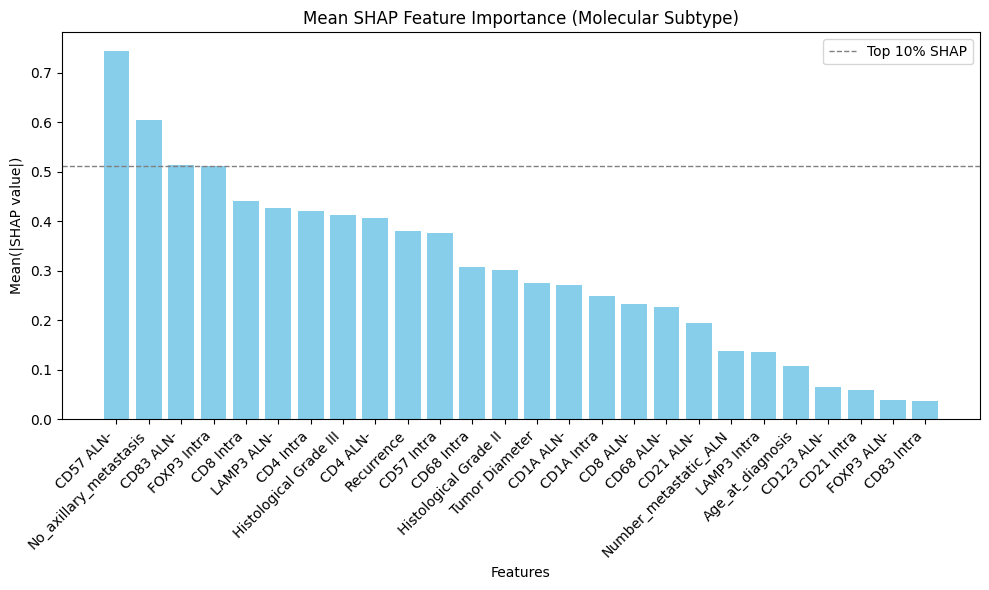

In [6]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/MolecularSubtype_Model1/RECURSIVE_METHOD"

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics
AUC = []
ACCURACY = []
RECALL = []

# Initialize structures to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions = 0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------
for file in files:
    full_dir = os.path.join(path, file)
    file_path = os.path.join(full_dir, "resultats_terminal.txt")

    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    repetitions += 1

    with open(file_path, "r", encoding="latin-1") as f: 
        lines = f.readlines()

    parse_shap = False

    for line in lines:
        line_stripped = line.strip()

        # ---------------- METRICS ----------------
        if line_stripped.startswith("AUC:"):
            try:
                AUC.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        elif line_stripped.startswith("Accuracy:"):
            try:
                ACCURACY.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        elif line_stripped.startswith("Recall:"):
            try:
                RECALL.append(float(line_stripped.split(":", 1)[1].strip()))
            except ValueError:
                continue

        # ---------------- SHAP SECTION ----------------
        elif line_stripped == "SHAP values feature importance:":
            parse_shap = True
            continue


        # ---------------- PARSE SHAP VALUES ----------------
        elif parse_shap:
            if ":" not in line_stripped:
                continue

            feature, value = line_stripped.split(":", 1)
            try:
                shap_value = float(value.strip())
            except ValueError:
                continue

            shap_values_dict.setdefault(feature.strip(), []).append(shap_value)

# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP VALUES ACROSS REPEATED RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_values_mean_sorted = dict(
    sorted({k: np.mean(v) for k, v in shap_values_dict.items()}.items(), key=lambda x: x[1], reverse=True)
)

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME FEATURES FOR FIGURES
# ----------------------------------------------------------------------------------------------------------------------------
feature_mapping = {
    "Age": "Age_at_diagnosis",
    "NodalStatus_Sin metastasis": "No_axillary_metastasis",
    "GangMeta": "Number_metastatic_ALN"
}

shap_values_mean_sorted = {
    feature_mapping.get(k, k): v
    for k, v in shap_values_mean_sorted.items()
}


# ----------------------------------------------------------------------------------------------------------------------------
# METRICS: MEAN, STD, MEDIAN, IQR
# ----------------------------------------------------------------------------------------------------------------------------
metrics = {
    'AUC': AUC,
    'Accuracy': ACCURACY,
    'Recall': RECALL
}

for metric_name, values in metrics.items():
    values_np = np.array(values)
    mean = np.mean(values_np)
    std = np.std(values_np)
    median = np.median(values_np)
    q1 = np.percentile(values_np, 25)
    q3 = np.percentile(values_np, 75)
    iqr = q3 - q1

    print(f"{metric_name}:")
    print(f"  Mean = {mean:.4f}, Std = {std:.4f}")
    print(f"  Median = {median:.4f}, IQR = {iqr:.4f}\n")

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

values = list(shap_values_mean_sorted.values())

plt.bar(shap_values_mean_sorted.keys(), values, color='skyblue')

# Compute top 10% cutoff
top_10_cutoff = np.percentile(values, 90)

# Add horizontal dashed line
plt.axhline(y=top_10_cutoff, color='gray', linestyle='--', linewidth=1, label='Top 10% SHAP')

plt.xlabel('Features')
plt.ylabel('Mean(|SHAP value|)')
plt.title('Mean SHAP Feature Importance (Molecular Subtype)')
plt.xticks(rotation=45, ha='right')

# Add legend
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# ----------------------------------------------------------------------------------------------------------------------------
# TOP 10% FEATURES (SHAP)
# ----------------------------------------------------------------------------------------------------------------------------

shap_values_array = np.array(list(shap_values_mean_sorted.values()))

shap_top10_cutoff = np.percentile(shap_values_array, 90)

top10_shap_features = {
    feature: value
    for feature, value in shap_values_mean_sorted.items()
    if value >= shap_top10_cutoff
}


print("TOP 10% SHAP FEATURES")

for rank, (feature, value) in enumerate(top10_shap_features.items(), start=1):
    print(f"{rank:2d}. {feature:30s} {value:.6f}")

print(f"\nNumber of SHAP top 10% features: {len(top10_shap_features)}")
print(f"SHAP cutoff (90th percentile): {shap_top10_cutoff:.6f}")


TOP 10% SHAP FEATURES
 1. CD57 ALN-                      0.744066
 2. No_axillary_metastasis         0.604291
 3. CD83 ALN-                      0.512499

Number of SHAP top 10% features: 3
SHAP cutoff (90th percentile): 0.511513


### Model 2: Incremental Feature Model Based on Importance Ranking

In [1]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/MolecularSubtype_Model2"

input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

os.makedirs(path, exist_ok=True)

feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace decimal commas with decimal points
db = db.replace(',', '.', regex=True)

# Replace empty or whitespace-only strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Convert DFS120 to numeric values
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')

# Remove variables that are not used in the analysis
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Invaperin'], errors='ignore')

# Define variables that should be treated as continuous numerical features
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']

# Convert numerical variables to float
for col in columns_float:
    if col in db.columns:
        db[col] = db[col].astype(float)

# Remove S100Intra_M from the analysis (extensive missing data)
db = db.drop(columns=['S100Intra_M'], errors='ignore')

# Remove missing values and reset index
db = db.dropna().reset_index(drop=True)

print(f"Dataset shape after cleaning: {db.shape}")

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE BINARY TARGET VARIABLE
# ----------------------------------------------------------------------------------------------------------------------------
# Define the binary target:
# Luminal = Luminal A or Luminal B
# Non-Luminal = Triple Negative or HER2-enriched
db['Luminal_binary'] = db['Luminal'].apply(
    lambda x: True if str(x).strip() in ['Luminal A', 'Luminal B'] else False
)

# Drop Luminal column now that target is created
db = db.drop(columns=['Luminal'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
# Convert categorical variables into binary dummy variables
db = pd.get_dummies(db, columns=['Grau', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])
db = db.drop(columns=['StatusDFS120_No'], errors='ignore')

# Rename variables for readability and consistency
variable_names = ['Age', 'Tumor Diameter', 'RE', 'RP', 'HER2', 'KI67', 'GangMeta',
                  'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-',
                  'CD21 Intra', 'CD21 ALN-', 'CD68 Intra', 'CD68 ALN-',
                  'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Luminal_binary',
                  'Histological Grade II', 'Histological Grade III',
                  'NodalStatus_Sin metastasis', 'Recurrence']

db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# ----------------------------------------------------------------------------------------------------------------------------
immune_features = ['CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']

clinicopathological_features = [
    'Age',
    'Tumor Diameter',
    'GangMeta',
    'Histological Grade II',
    'Histological Grade III',
    'NodalStatus_Sin metastasis',
    'Recurrence'
]

# Combine immune and clinicopathological features
all_features = immune_features + clinicopathological_features

# Define numerical variables
variables_numericas = immune_features + ['Age', 'Tumor Diameter', 'GangMeta']

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE PREDICTORS AND TARGET
# ----------------------------------------------------------------------------------------------------------------------------
x = db[all_features]
y = db['Luminal_binary']

print("\nOriginal distribution:")
print(Counter(y))

# ----------------------------------------------------------------------------------------------------------------------------
# SHAP-RANKED FEATURE LIST
# ----------------------------------------------------------------------------------------------------------------------------
# Features ranked according to their mean SHAP importance from Model 1
feature_list = ['CD57 ALN-', 'NodalStatus_Sin metastasis','CD83 ALN-','FOXP3 Intra','CD8 Intra','LAMP3 ALN-','CD4 Intra',
                'Histological Grade III','CD4 ALN-','Recurrence','CD57 Intra','CD68 Intra','Histological Grade II','Tumor Diameter',
                'CD1A ALN-','CD1A Intra','CD8 ALN-','CD68 ALN-','CD21 ALN-',   'GangMeta','LAMP3 Intra','Age','CD123 ALN-', 
                'CD21 Intra','FOXP3 ALN-','CD83 Intra']            

# Initialize the list of features included in the model
feature_using = []

# Counter to keep track of how many features have been added
feature_number = 0

# ----------------------------------------------------------------------------------------------------------------------------
# SEQUENTIAL FEATURE INCLUSION
# ----------------------------------------------------------------------------------------------------------------------------
# Sequentially add SHAP-ranked features to the model
for feature1 in feature_list:
    
    feature_using.append(feature1)
    feature_number = feature_number + 1
    
    # Print the feature name to track process
    print(feature1)
    
    # Repeat the train/test split and model evaluation for 100 random states
    for i in range(0, 100):
        random_num = i
        # Create directories for the current feature set and random state
        os.makedirs(f'{path}/FEATURE_{feature_number}_{feature1}', exist_ok=True)
        os.makedirs(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}', exist_ok=True)
        print('Random State:', random_num)
        
        # Create a log file to record the results for the current iteration
        new_file = open(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/resultats_terminal.txt', 'w')
        new_file.write('Random State: ' + str(random_num) + '\n')
        
        # ----------------------------------------------------------------------
        # TRAIN/TEST SPLIT
        # ----------------------------------------------------------------------
        # Split the dataset into training and test sets while preserving class proportions
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_num, shuffle=True, stratify=y)

        # ----------------------------------------------------------------------
        # CHECK CLASS DISTRIBUTION
        # ----------------------------------------------------------------------
        # Record the class distribution in the complete dataset, training set, and test set
        counter = Counter(y)
        counter_test = Counter(y_test)
        new_file.write('\n' + 'y: ' + str(counter) + '\n')
        new_file.write('y test: ' + str(counter_test) + '\n')
        counter = Counter(y_train)
        new_file.write('y train: ' + str(counter) + '\n')

        # ----------------------------------------------------------------------
        # FEATURE SCALING
        # ----------------------------------------------------------------------
        # Standardize features using parameters estimated from the training set only
        scaler = StandardScaler()
        scaler_fit = scaler.fit(x_train[feature_using])
        
        x_train_scaled = pd.DataFrame(
            scaler_fit.transform(x_train[feature_using]),
            columns=feature_using,
            index=x_train.index
        )
        
        # Apply the training-set scaling parameters to the test set
        x_test_scaled = pd.DataFrame(
            scaler_fit.transform(x_test[feature_using]),
            columns=feature_using,
            index=x_test.index
        )
        
        # ----------------------------------------------------------------------
        # LOGISTIC REGRESSION HYPERPARAMETER OPTIMIZATION
        # ----------------------------------------------------------------------        
        # 3-fold stratified cross-validation
        cv = StratifiedKFold(3)

        # Define the hyperparameter search space
        param_dist = {
            'classifier__penalty': ['l1', 'l2'],
            'classifier__C': np.logspace(-4, 4, 20),
            'classifier__solver': ['liblinear', 'saga'],
            'classifier__max_iter': [500, 1000, 2000]
        }

        # Use ROC AUC as the optimization metric
        scoring = 'roc_auc'
        new_file.write('\n' + 'Scoring: ' + str(scoring) + '\n')

        # ----------------------------------------------------------------------
        # INITIALIZE LOGISTIC REGRESSION
        # ----------------------------------------------------------------------  
        # Initialize logistic regression with balanced class weights
        lr_classifier = LogisticRegression(class_weight='balanced', random_state=random_num)

        # ----------------------------------------------------------------------
        # HYPERPARAMETER SEARCH
        # ----------------------------------------------------------------------  
        # Define the pipeline
        pipeline = Pipeline([
            ('classifier', lr_classifier)
        ])
        
        # Perform randomized hyperparameter search using 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(estimator=pipeline, scoring=scoring, param_distributions=param_dist, cv=cv, verbose=0, random_state=random_num, n_jobs=-1)
        random_search.fit(x_train_scaled, y_train)

        # ----------------------------------------------------------------------
        # MODEL TRAINING
        # ----------------------------------------------------------------------  
        # Keep the scaled training and test sets for consistency with the previous workflow
        x_train_rfecv = x_train_scaled
        x_test_rfecv = x_test_scaled

        # Retrieve the best hyperparameters identified during the randomized search
        best_params = random_search.best_params_
        
        # Remove the pipeline prefix from the parameter names
        cleaned_best_params = {param.split('__')[1]: value for param, value in best_params.items()}

        # Initialize the final logistic regression model using the optimized hyperparameters
        best_lr = LogisticRegression(**cleaned_best_params, class_weight='balanced', random_state=random_num)

        # Fit the final model on the training set
        best_lr.fit(x_train_rfecv, y_train)

        # Generate predictions for the test set
        result_lr = best_lr.predict(x_test_rfecv)

        # ----------------------------------------------------------------------
        # CROSS-VALIDATION PERFORMANCE
        # ----------------------------------------------------------------------
        # Evaluate ROC AUC using 3-fold cross-validation on the training set
        scores = cross_val_score(best_lr, x_train_rfecv, y_train, cv=cv, scoring=scoring)
        new_file.write('\n' + 'Metricas cross_validation: ' + str(scores))
        new_file.write('\n' + 'Media de cross_validation: ' + str(scores.mean()) + ' ' + str(np.std(scores)) + '\n')

        # ----------------------------------------------------------------------
        # TEST SET PERFORMANCE
        # ----------------------------------------------------------------------
        # Generate the classification report for the test set
        prec_rec = classification_report(y_test, result_lr)
        new_file.write('\n' + str(prec_rec) + '\n')

        # Calculate ROC AUC on the independent test set
        auc = roc_auc_score(y_test, best_lr.predict_proba(x_test_rfecv)[:, 1])
        new_file.write('\n' + 'AUC: ' + str(auc) + '\n')

        # Calculate test-set accuracy
        accuracy = accuracy_score(y_test, result_lr)
        new_file.write('\n' + 'Accuracy: ' + str(accuracy) + '\n')

        # ----------------------------------------------------------------------
        # LOGISTIC REGRESSION FEATURE IMPORTANCE
        # ----------------------------------------------------------------------
        # Extract logistic regression coefficients
        coefs = best_lr.coef_[0]
        
        # Retrieve the names of the features used by the model
        feature_names = x_test_scaled.columns if hasattr(x_test_scaled, 'columns') else np.array(feature_using)
        
        # Save feature coefficients to the results file
        new_file.write('\nFeature importances (coefficients):\n')
        for feature, coef in zip(feature_names, coefs):
            new_file.write(f"{feature}: {coef} ")
        
        # Calculate absolute coefficient values as a measure of feature importance
        coef_abs = np.abs(coefs)
        
        # Sort features according to their absolute coefficient magnitude
        coef_sorted_idx = np.argsort(coef_abs)
        sorted_features = np.array(feature_names)[coef_sorted_idx]
        sorted_importance = coef_abs[coef_sorted_idx]
        
        new_file.write('\nFeatures sorted: ' + str(sorted_features) + '\n')
        
        # Plot feature importance
        plt.grid(False)
        indices = np.arange(0, len(coef_abs)) + 0.5
        
        plt.barh(indices, sorted_importance, height=0.7)
        plt.yticks(indices, sorted_features)
        
        plt.ylim((0, len(coef_abs)))
        plt.xlabel("|Coefficient| (absolute importance)")
        plt.title("LOGISTIC REGRESSION")
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/LR_{random_num}.png', bbox_inches='tight')
        plt.close()

        # ----------------------------------------------------------------------
        # SHAP ANALYSIS
        # ----------------------------------------------------------------------
        # Initialize the SHAP explainer for the logistic regression model
        explainer = shap.LinearExplainer(best_lr, masker=shap.maskers.Independent(x_train_rfecv))
        
        # Calculate SHAP values for the test set
        shap_values = explainer.shap_values(x_test_rfecv)
        new_file.write('\n' + 'SHAP values feature importance: ' + '\n')

        # Calculate mean absolute SHAP value for each feature
        shap_values_per_feature = np.abs(shap_values).mean(axis=0)

        # Save mean absolute SHAP values for each feature
        cont = 0
        for feature in x_train[feature_using].columns:
            new_file.write(f'{feature}: {shap_values_per_feature[cont]}' + '\n')
            cont = cont + 1
        
        # Shap summary bar plot 
        shap.summary_plot(shap_values, x_test_rfecv, show=False)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_summary_point_{random_num}.png', bbox_inches='tight')
        plt.close()
        
        # Shap decision plot for a single test instance
        idx = -1  
        shap.decision_plot(explainer.expected_value, shap_values[idx, :], x_test_rfecv.columns, show=False)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_decision_{random_num}.png', bbox_inches='tight')
        plt.close()
        
        new_file.close()

Dataset shape after cleaning: (142, 32)

Original distribution:
Counter({True: 81, False: 61})
CD57 ALN-
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8


C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random State: 9
Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random State: 24
Random State: 25
Random State: 26
Random State: 27
Random State: 28
Random State: 29
Random State: 30
Random State: 31
Random State: 32
Random State: 33
Random State: 34
Random State: 35
Random State: 36
Random State: 37
Random State: 38
Random State: 39
Random State: 40
Random State: 41
Random State: 42
Random State: 43
Random State: 44
Random State: 45
Random State: 46
Random State: 47
Random State: 48
Random State: 49
Random State: 50
Random State: 51
Random State: 52
Random State: 53
Random State: 54
Random State: 55
Random State: 56
Random State: 57
Random State: 58
Random State: 59
Random State: 60
Random State: 61
Random State: 62
Random State: 63
Random State: 64
Random State: 65
Random State: 66
Random State: 6

C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random State: 80
Random State: 81
Random State: 82
Random State: 83
Random State: 84
Random State: 85
Random State: 86
Random State: 87
Random State: 88
Random State: 89
Random State: 90
Random State: 91
Random State: 92
Random State: 93
Random State: 94
Random State: 95
Random State: 96
Random State: 97
Random State: 98
Random State: 99
CD83 ALN-
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8
Random State: 9
Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random State: 24
Random State: 25
Random State: 26
Random State: 27
Random State: 28
Random State: 29
Random State: 30
Random State: 31
Random State: 32
Random State: 33
Random State: 34
Random State: 35
Random State: 36
Random State: 37
Random State: 

...

Random State: 88
Random State: 89
Random State: 90
Random State: 91
Random State: 92
Random State: 93
Random State: 94
Random State: 95
Random State: 96
Random State: 97
Random State: 98
Random State: 99
FOXP3 ALN-
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8
Random State: 9
Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random State: 24
Random State: 25
Random State: 26
Random State: 27
Random State: 28
Random State: 29
Random State: 30
Random State: 31
Random State: 32
Random State: 33
Random State: 34
Random State: 35
Random State: 36
Random State: 37
Random State: 38
Random State: 39
Random State: 40
Random State: 41
Random State: 42
Random State: 43
Random State: 44
Random State: 45
Random State:

C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random State: 88
Random State: 89
Random State: 90
Random State: 91
Random State: 92
Random State: 93
Random State: 94
Random State: 95
Random State: 96
Random State: 97
Random State: 98
Random State: 99
CD83 Intra
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8
Random State: 9
Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random State: 24
Random State: 25
Random State: 26
Random State: 27
Random State: 28
Random State: 29
Random State: 30
Random State: 31
Random State: 32
Random State: 33
Random State: 34
Random State: 35
Random State: 36
Random State: 37
Random State: 38
Random State: 39
Random State: 40
Random State: 41
Random State: 42
Random State: 43
Random State: 44
Random State: 45
Random State:

C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\UX534\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random State: 88
Random State: 89
Random State: 90
Random State: 91
Random State: 92
Random State: 93
Random State: 94
Random State: 95
Random State: 96
Random State: 97
Random State: 98
Random State: 99


### Model 2 Statistics

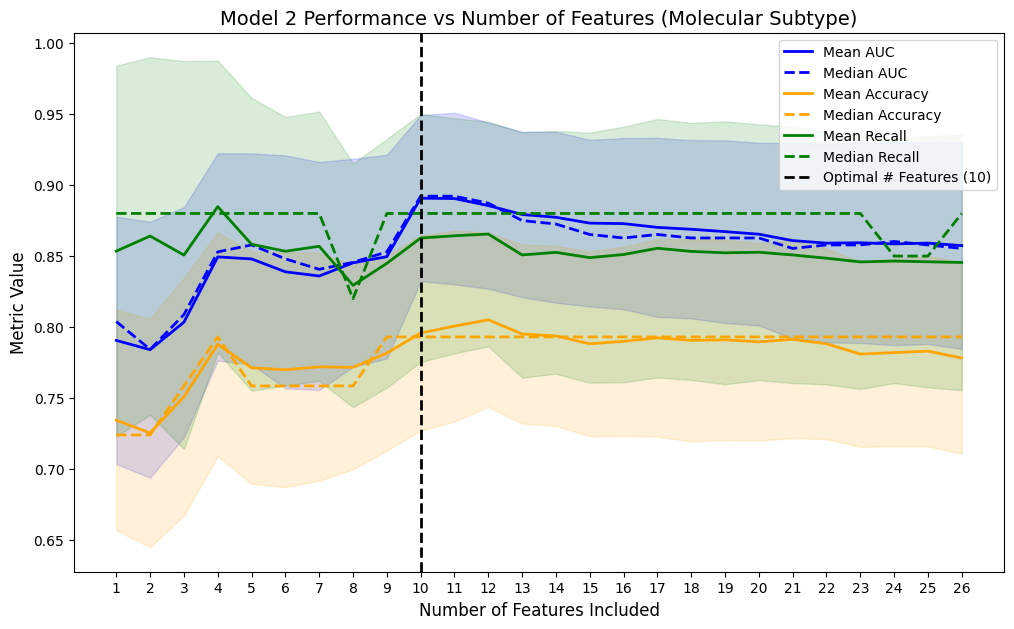


 Optimal number of features: 10

--- Final Statistics (Feature set #10) ---
AVERAGE AUC:       0.891
STD AUC:           0.058
MEDIAN AUC:        0.892
RIQ AUC:           0.078

AVERAGE ACCURACY:  0.796
STD ACCURACY:      0.069
MEDIAN ACCURACY:   0.793
RIQ ACCURACY:      0.069

AVERAGE RECALL:    0.863
STD RECALL:        0.087
MEDIAN RECALL:     0.880
RIQ RECALL:        0.120


In [8]:
# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
base_path = "../results/MolecularSubtype_Model2"

# List all feature folders (sorted by feature number)
feature_folders = sorted(
    [f for f in os.listdir(base_path) if f.startswith("FEATURE_")],
    key=lambda x: int(x.split("_")[1])
)

# Initialize lists to store metrics for each feature count
metrics_AUC = []
metrics_Accuracy = []
metrics_Recall = []

# ----------------------------------------------------------------------------------------------------------------------------
# READ METRICS FROM ALL RESULT FILES
# ----------------------------------------------------------------------------------------------------------------------------
for folder in feature_folders:
    folder_path = os.path.join(base_path, folder)
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
    
    auc_list, acc_list, recall_list = [], [], []
    
    for sub in subfolders:
        result_file = os.path.join(folder_path, sub, "resultats_terminal.txt")
        if not os.path.exists(result_file):
            continue
        
        with open(result_file, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            if line.startswith('AUC:'):
                auc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('Accuracy:'):
                acc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('AVERAGE RECALL:'):
                recall_list.append(float(line.split(":")[1].strip()))

            elif line.strip().startswith("True"):
                parts = line.split()
                try:
                    recall_value = float(parts[2])
                    recall_list.append(recall_value)
                except (ValueError, IndexError):
                    pass
    
    metrics_AUC.append(auc_list)
    metrics_Accuracy.append(acc_list)
    metrics_Recall.append(recall_list)

# ----------------------------------------------------------------------------------------------------------------------------
# COMPUTE MEAN, MEDIAN AND STD FOR EACH NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
mean_auc   = [np.mean(m) for m in metrics_AUC]
median_auc = [np.median(m) for m in metrics_AUC]
std_auc    = [np.std(m) for m in metrics_AUC]

mean_acc   = [np.mean(m) for m in metrics_Accuracy]
median_acc = [np.median(m) for m in metrics_Accuracy]
std_acc    = [np.std(m) for m in metrics_Accuracy]

mean_rec   = [np.mean(m) for m in metrics_Recall]
median_rec = [np.median(m) for m in metrics_Recall]
std_rec    = [np.std(m) for m in metrics_Recall]

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT PERFORMANCE EVOLUTION BY NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
x = np.arange(1, len(mean_auc) + 1)

plt.figure(figsize=(12,7))

# AUC
plt.plot(x, mean_auc, color='blue', linewidth=2, label='Mean AUC')
plt.plot(x, median_auc, color='blue', linestyle='--', linewidth=2, label='Median AUC')

plt.fill_between(
    x,
    np.array(mean_auc) - np.array(std_auc),
    np.array(mean_auc) + np.array(std_auc),
    color='blue',
    alpha=0.15
)

# Accuracy
plt.plot(x, mean_acc, color='orange', linewidth=2, label='Mean Accuracy')
plt.plot(x, median_acc, color='orange', linestyle='--', linewidth=2, label='Median Accuracy')

plt.fill_between(
    x,
    np.array(mean_acc) - np.array(std_acc),
    np.array(mean_acc) + np.array(std_acc),
    color='orange',
    alpha=0.15
)

# Recall
plt.plot(x, mean_rec, color='green', linewidth=2, label='Mean Recall')
plt.plot(x, median_rec, color='green', linestyle='--', linewidth=2, label='Median Recall')

plt.fill_between(
    x,
    np.array(mean_rec) - np.array(std_rec),
    np.array(mean_rec) + np.array(std_rec),
    color='green',
    alpha=0.15
)

# Optimal number of features
optimal_features = np.argmax(mean_auc) + 1

plt.axvline(
    optimal_features,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Optimal # Features ({optimal_features})'
)

# Labels and title
plt.xlabel('Number of Features Included', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.title('Model 2 Performance vs Number of Features (Molecular Subtype)', fontsize=14)
plt.xticks(x)


# Legend
plt.legend(
    loc='upper right',
    frameon=True,
    fontsize=10
)

plt.show()

print(f"\n Optimal number of features: {optimal_features}")

# ----------------------------------------------------------------------------------------------------------------------------
# FINAL STATISTICS (FOR THE OPTIMAL FEATURE SET)
# ----------------------------------------------------------------------------------------------------------------------------
def metric_stats(metric_list):
    metric_list = [x for x in metric_list if not np.isnan(x)]
    if len(metric_list) == 0:
        return {"mean": np.nan, "std": np.nan, "median": np.nan, "iqr": np.nan}
    return {
        "mean": np.mean(metric_list),
        "std": np.std(metric_list),
        "median": np.median(metric_list),
        "iqr": np.percentile(metric_list, 75) - np.percentile(metric_list, 25)
    }

print(f"\n--- Final Statistics (Feature set #{optimal_features}) ---")

auc_stats = metric_stats(metrics_AUC[optimal_features - 1])
acc_stats = metric_stats(metrics_Accuracy[optimal_features - 1])
rec_stats = metric_stats(metrics_Recall[optimal_features - 1])

print(f"AVERAGE AUC:       {auc_stats['mean']:.3f}")
print(f"STD AUC:           {auc_stats['std']:.3f}")
print(f"MEDIAN AUC:        {auc_stats['median']:.3f}")
print(f"RIQ AUC:           {auc_stats['iqr']:.3f}\n")

print(f"AVERAGE ACCURACY:  {acc_stats['mean']:.3f}")
print(f"STD ACCURACY:      {acc_stats['std']:.3f}")
print(f"MEDIAN ACCURACY:   {acc_stats['median']:.3f}")
print(f"RIQ ACCURACY:      {acc_stats['iqr']:.3f}\n")

print(f"AVERAGE RECALL:    {rec_stats['mean']:.3f}")
print(f"STD RECALL:        {rec_stats['std']:.3f}")
print(f"MEDIAN RECALL:     {rec_stats['median']:.3f}")
print(f"RIQ RECALL:        {rec_stats['iqr']:.3f}")

0
1
10
11
12
13
14
15
16
17
18
19
2
20
21
22
23
24
25
26
27
28
29
3
30
31
32
33
34
35
36
37
38
39
4
40
41
42
43
44
45
46
47
48
49
5
50
51
52
53
54
55
56
57
58
59
6
60
61
62
63
64
65
66
67
68
69
7
70
71
72
73
74
75
76
77
78
79
8
80
81
82
83
84
85
86
87
88
89
9
90
91
92
93
94
95
96
97
98
99


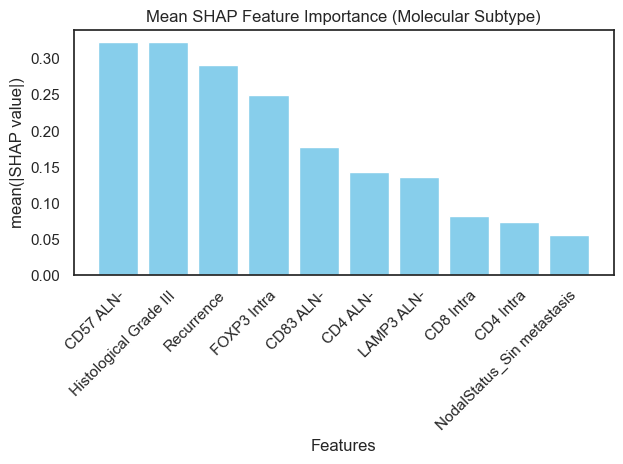

In [35]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
# Define the current feature name being analyzed 
feature = "FEATURE_10_Recurrence"

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path1 ="../results/MolecularSubtype_Model2"
path = f'{path1}/{feature}'

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics and features
AUC = []
ACCURACY = []
RECALL = []
features = []

# Initialize dictionary to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions =  0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------
for file in files:
    full_dir = os.path.join(path, file)
    
    # Skip if it's not a directory
    if not os.path.isdir(full_dir):
        continue

    print(file)
    repetitions += 1

    file_path = os.path.join(full_dir, "resultats_terminal.txt")
    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    with open(file_path, "r") as f:
        lines = f.readlines()
    
    # Path to the text file containing metrics and SHAP information
    file_path = f'{path}/{file}/resultats_terminal.txt'
    lines = [line for line in open(file_path, 'r')]
    
    # Flag to identify when SHAP section starts
    features_sorted_reached = False

    for line in lines:
        if line.startswith('AUC'):
            AUC.append(float(line.split()[1]))
            
        if line.startswith('Accuracy'):
            ACCURACY.append(float(line.split()[1]))
            
        if line.strip().startswith("True"):
            parts = line.split()
            # The recall column is the 3rd numeric value (index 2)
            if len(parts) >= 3:
                RECALL.append(float(parts[2]))
            
        # Detect beginning of SHAP feature importance section   
        if line.startswith('SHAP values '):
            features_sorted_reached = True
            continue
        
        # Parse SHAP feature importances once section starts
        if features_sorted_reached:
            shap_values_lines = line.strip().split(":")
            feature_name = shap_values_lines[0].strip()
            feature_value = float(shap_values_lines[1])
            
            # Add or append SHAP values for each feature
            if feature_name in shap_values_dict:
                shap_values_dict[feature_name].append(feature_value)
            else:
                shap_values_dict[feature_name] = [feature_value]
    
# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP VALUES ACROSS REPEATED RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_values_dict_sum = {}

for key, values in shap_values_dict.items():
    # Compute mean SHAP importance across all repetitions
    shap_value_sum = sum(values)
    shap_values_dict_sum[key] = shap_value_sum/repetitions
    
# Sort features by mean SHAP importance in descending order         
shap_values_dict_sum_sorted = dict(sorted(shap_values_dict_sum.items(), key=lambda item: item[1], reverse=True))

# ----------------------------------------------------------------------------------------------------------------------------
# SAVE PERFORMANCE METRICS AND CREATE TEXT FILE
# ----------------------------------------------------------------------------------------------------------------------------
# Convert metric lists to NumPy arrays and transpose for DataFrame alignment
AUC_T = np.transpose(AUC)
ACCURACY_T = np.transpose(ACCURACY)
RECALL_T = np.transpose(RECALL)

# Create a pandas DataFrame containing all performance metrics
df = pd.DataFrame([AUC, ACCURACY, RECALL]).T
df.columns = ['AUC','ACCURACY','RECALL']

# Export metrics to an Excel file
df.to_excel(f'{path}/{feature}.xlsx', index=False)

# Create or overwrite a text file for additional summary outputs
new_file = open(f'{path}/{feature}.txt', 'w')

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
plt.bar(shap_values_dict_sum_sorted.keys(), shap_values_dict_sum_sorted.values(), color='skyblue')
plt.xlabel('Features')
plt.title('Mean SHAP Feature Importance (Molecular Subtype)')
plt.ylabel('mean(|SHAP value|)')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

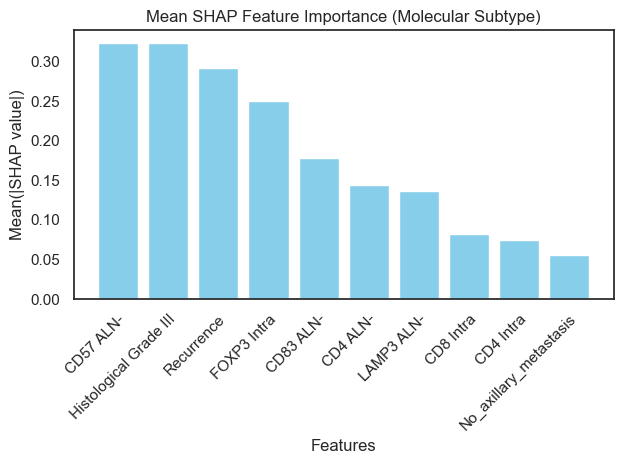

In [38]:
# ----------------------------------------------------------------------------------------------------------------------------
# FEATURE NAME MAPPING FOR FIGURES
# ----------------------------------------------------------------------------------------------------------------------------

feature_name_mapping = {
    'NodalStatus_Sin metastasis': 'No_axillary_metastasis'
}

# Rename features only for visualization
shap_values_dict_sum_sorted_plot = {
    feature_name_mapping.get(k, k): v
    for k, v in shap_values_dict_sum_sorted.items()
}

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------

plt.bar(
    shap_values_dict_sum_sorted_plot.keys(),
    shap_values_dict_sum_sorted_plot.values(),
    color='skyblue'
)

plt.xlabel('Features')
plt.ylabel('Mean(|SHAP value|)')
plt.title('Mean SHAP Feature Importance (Molecular Subtype)')

plt.xticks(
    rotation=45,
    ha='right',
    rotation_mode='anchor'
)

plt.tight_layout()
plt.show()